# XGBoost Baseline for Indian CPI Inflation

This notebook builds the first baseline `XGBRegressor` model for forecasting `cpi_headline_yoy` using the full set of explanatory variables.

## 1. Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

## 2. Load Dataset

In [2]:
import pandas as pd

DATASET_PATH = "../Capstone-project/processed_capstone_dataset_2001_2025.csv"

df = pd.read_csv(DATASET_PATH)

print(f"Dataset shape: {df.shape}")

Dataset shape: (300, 67)


## 3. Data Preparation

In [3]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())

Date range: 2001-01-01 to 2025-12-01


## 4. Define Target and Features

In [4]:
target_column = "cpi_headline_yoy"

X = df.drop(columns=[target_column]).copy()
X.drop(columns=["cpi_headline_index"], inplace=True)
X.drop(columns=["Date"], inplace=True)

y = df[target_column].copy()
dates = df["Date"].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

Feature matrix shape: (300, 64)
Target shape: (300,)


## 5. Time-Based Train/Test Split

In [5]:
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

dates_train = dates.iloc[:split_index]
dates_test = dates.iloc[split_index:]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print(f"Training date range: {dates_train.min().date()} to {dates_train.max().date()}")
print(f"Test date range: {dates_test.min().date()} to {dates_test.max().date()}")

X_train shape: (240, 64)
X_test shape: (60, 64)
y_train shape: (240,)
y_test shape: (60,)
Training date range: 2001-01-01 to 2020-12-01
Test date range: 2021-01-01 to 2025-12-01


## 6. Train XGBoost

In [6]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


## 7. Test Predictions

In [7]:
y_pred = model.predict(X_test)

results_df = pd.DataFrame(
    {
        "Date": dates_test.values,
        "Actual": y_test.values,
        "Predicted": y_pred,
    }
)

results_df

,Date,Actual,Predicted
0,2021-01-01,4.061252,4.248521
1,2021-02-01,5.030181,5.265933
2,2021-03-01,5.518170,5.840233
3,2021-04-01,4.227213,6.001747
4,2021-05-01,6.295560,5.792159
5,2021-06-01,6.258235,5.748964
6,2021-07-01,5.588044,5.379342
7,2021-08-01,5.300582,5.273343
8,2021-09-01,4.347826,5.651011
9,2021-10-01,4.482323,5.444301


## 8. Evaluation Metrics

In [8]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

non_zero_mask = np.abs(y_test.values) > 1e-6
if non_zero_mask.any():
    mape = np.mean(
        np.abs((y_test.values[non_zero_mask] - y_pred[non_zero_mask]) / y_test.values[non_zero_mask])
    ) * 100
else:
    mape = np.nan

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.2f}%")

RMSE: 2.0978
MAE: 1.8251
MAPE: 76.95%


## 9. Actual vs Predicted Plot

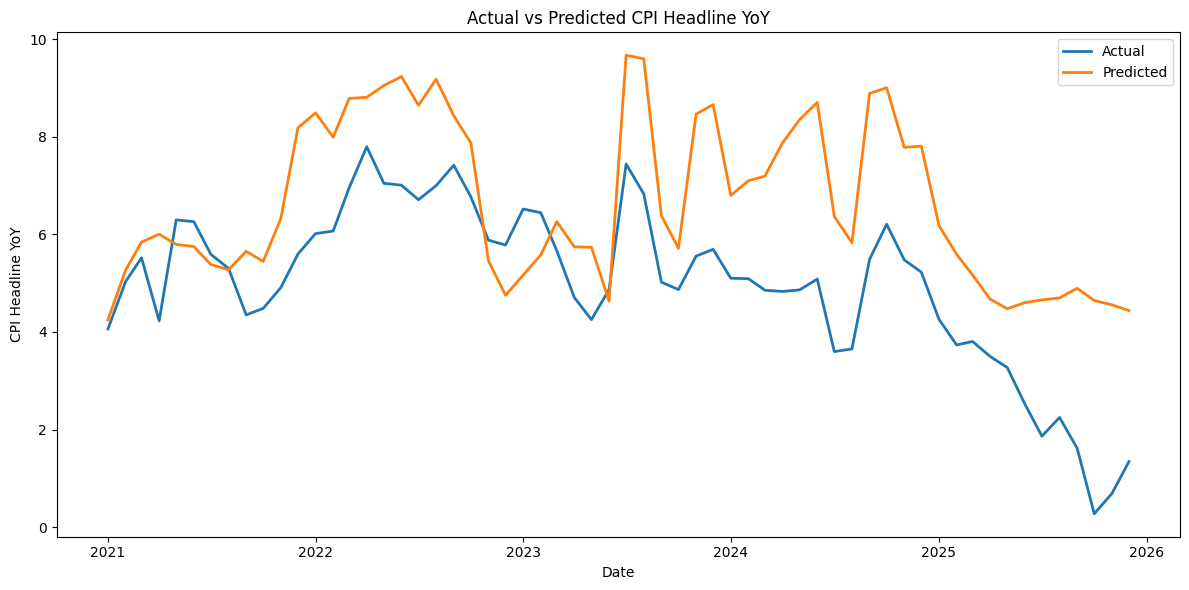

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(results_df["Date"], results_df["Actual"], label="Actual", linewidth=2)
plt.plot(results_df["Date"], results_df["Predicted"], label="Predicted", linewidth=2)
plt.title("Actual vs Predicted CPI Headline YoY")
plt.xlabel("Date")
plt.ylabel("CPI Headline YoY")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Top Feature Importance

In [10]:
feature_importance_df = pd.DataFrame(
    {
        "feature": X_train.columns,
        "importance": model.feature_importances_,
    }
).sort_values("importance", ascending=False)

feature_importance_df.head(20).reset_index(drop=True)

,feature,importance
0,MABMM301INM189N,0.314073
1,wpi_primary_food_articles_yoy,0.133599
2,global_fertilizer_index,0.095403
3,palm_oil_usd,0.070845
4,crude_oil_brent_usd,0.040627
5,wpi_rice_yoy,0.030021
6,wpi_arhar_tur,0.029441
7,wpi_soybean_oil,0.027724
8,wpi_milk_yoy,0.027419
9,wpi_primary_food_articles,0.024515
